# Publieke laadpunten per 1.000 huishoudens per gemeente

Dit notebook maakt een kaart van het aantal regulier publieke laadpunten per 1.000 huishoudens in alle Nederlandse gemeenten.

**Benodigde bestanden (in dezelfde map als dit notebook):**
- `laadpunten_inkomens_gemerged_dataframe.csv`: laadpunten (NAL, juli 2026) en huishoudens/inkomen (CBS 86161NED, 2024*) per gemeente
- `gemeenten_2024.gpkg` (of `cbsgebiedsindelingen2024.gpkg`): gemeentegrenzen van CBS/PDOK, gebiedsindeling 2024

In [6]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## 1. Data inlezen

Het gemergde bestand bevat het aantal laadpunten en het aantal huishoudens (in duizenden) per gemeente. We rekenen de huishoudens om naar echte aantallen en berekenen het aantal laadpunten per 1.000 huishoudens.

In [7]:
df = pd.read_csv("laadpunten_inkomens_gemerged_dataframe.csv")

# Huishoudens staan in duizenden -> omrekenen naar echte aantallen
df["huishoudens"] = df["Particuliere huishoudens (x 1 000)"] * 1000

# Laadpunten per 1.000 huishoudens
df["laadpunten_per_1000_huishoudens"] = df["laadpunten"] / df["huishoudens"] * 1000

data = df[["gemeente", "laadpunten_per_1000_huishoudens"]].copy()
print("Aantal gemeenten:", len(data))
display(data.head())

Aantal gemeenten: 342


,gemeente,laadpunten_per_1000_huishoudens
0,Aa en Hunze,7.807018
1,Aalsmeer,22.253521
2,Aalten,11.794872
3,Achtkarspelen,4.500000
4,Alblasserdam,21.529412


## 2. Gemeentegrenzen inlezen

We gebruiken de gemeentegrenzen van CBS/PDOK (gebiedsindeling 2024, gegeneraliseerd). Eerst wordt het kleine bestand `gemeenten_2024.gpkg` gezocht, daarna het volledige `cbsgebiedsindelingen2024.gpkg`. Staat geen van beide in de map, dan worden de grenzen direct van PDOK gedownload.

In [8]:
laag = "gemeente_gegeneraliseerd"

if os.path.exists("gemeenten_2024.gpkg"):
    gemeenten = gpd.read_file("gemeenten_2024.gpkg", layer=laag)
elif os.path.exists("cbsgebiedsindelingen2024.gpkg"):
    gemeenten = gpd.read_file("cbsgebiedsindelingen2024.gpkg", layer=laag)
else:
    url = ("https://service.pdok.nl/cbs/gebiedsindelingen/2024/wfs/v1_0"
           "?request=GetFeature&service=WFS&version=2.0.0"
           "&typeName=gemeente_gegeneraliseerd&outputFormat=json")
    gemeenten = gpd.read_file(url)

print("Aantal gemeenten op de kaart:", len(gemeenten))
display(gemeenten.head())

Aantal gemeenten op de kaart: 342


,statcode,jrstatcode,statnaam,rubriek,id,geometry
0,GM0014,2024GM0014,Groningen,gemeente,1,"MULTIPOLYGON (((245194.691 592594.007, 245344...."
1,GM0034,2024GM0034,Almere,gemeente,2,"MULTIPOLYGON (((146891.056 493291.709, 147422...."
2,GM0037,2024GM0037,Stadskanaal,gemeente,3,"MULTIPOLYGON (((263763.866 566430.392, 263988...."
3,GM0047,2024GM0047,Veendam,gemeente,4,"MULTIPOLYGON (((256231.909 572319.213, 258595...."
4,GM0050,2024GM0050,Zeewolde,gemeente,5,"MULTIPOLYGON (((170596.293 486786.456, 170560...."


## 3. Gemeentenamen gelijk maken

CBS gebruikt voor een paar gemeenten een andere schrijfwijze dan het laadpuntenbestand, bijvoorbeeld *'s-Gravenhage* in plaats van *Den Haag*. Die namen maken we gelijk, zodat elke gemeente gekoppeld kan worden.

In [9]:
naam_mapping = {
    "'s-Gravenhage": "Den Haag",
    "Beek (L.)": "Beek",
    "Hengelo (O.)": "Hengelo",
    "Laren (NH.)": "Laren",
    "Middelburg (Z.)": "Middelburg",
    "Rijswijk (ZH.)": "Rijswijk",
    "Stein (L.)": "Stein",
}
gemeenten["gemeente"] = gemeenten["statnaam"].replace(naam_mapping)

# Controle: beide regels moeten set() geven
print("Alleen op de kaart:", set(gemeenten["gemeente"]) - set(data["gemeente"]))
print("Alleen in de data:", set(data["gemeente"]) - set(gemeenten["gemeente"]))

Alleen op de kaart: set()
Alleen in de data: set()


## 4. Data koppelen aan de kaart

In [10]:
kaart = gemeenten.merge(data, on="gemeente", how="left")
print("Gemeenten zonder data:", kaart["laadpunten_per_1000_huishoudens"].isna().sum())

Gemeenten zonder data: 0


## 5. Kaart maken

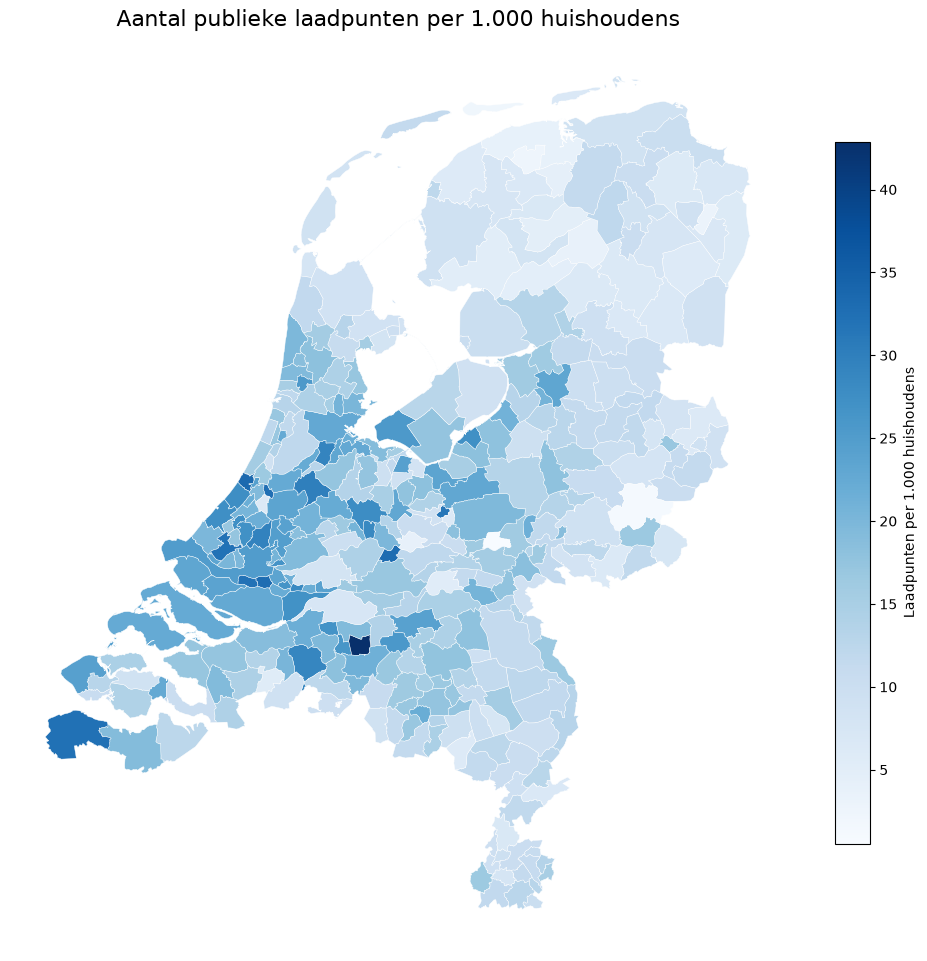

In [11]:
fig, ax = plt.subplots(figsize=(10, 12))

kaart.plot(
    column="laadpunten_per_1000_huishoudens",
    cmap="Blues",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Laadpunten per 1.000 huishoudens", "shrink": 0.6},
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Geen data"},
)

ax.set_title("Aantal publieke laadpunten per 1.000 huishoudens", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("kaart_laadpunten_per_1000_huishoudens.png", dpi=200)
plt.show()